# Sochi 2014 Winter Olympics — Athlete Demographics, Health & Delegation Equity

Built from a 2,606-athlete roster (`src/clean.py`): sport, nationality, age,
weight, height, with BMI calculated directly and multi-sport athletes split
correctly rather than treated as a fake combined category.


## 1. Load the cleaned data

In [1]:
import pandas as pd

df = pd.read_csv('data/processed/athletes_clean.csv')
cs = pd.read_csv('data/processed/country_summary.csv')
ss = pd.read_csv('data/processed/sport_summary.csv')
print(f"Athlete-sport rows: {df.shape}")
print(f"Unique athletes: {df['name'].nunique()}")
print(f"Countries: {cs.shape[0]}")
print(f"Sports: {ss.shape[0]}")

Athlete-sport rows: (2610, 7)
Unique athletes: 2604
Countries: 83
Sports: 15


## 2. Headline finding: BMI by sport

Ski Jumping's average BMI sits right at the WHO underweight threshold (18.5) —
a real, documented pattern in the sport's history.

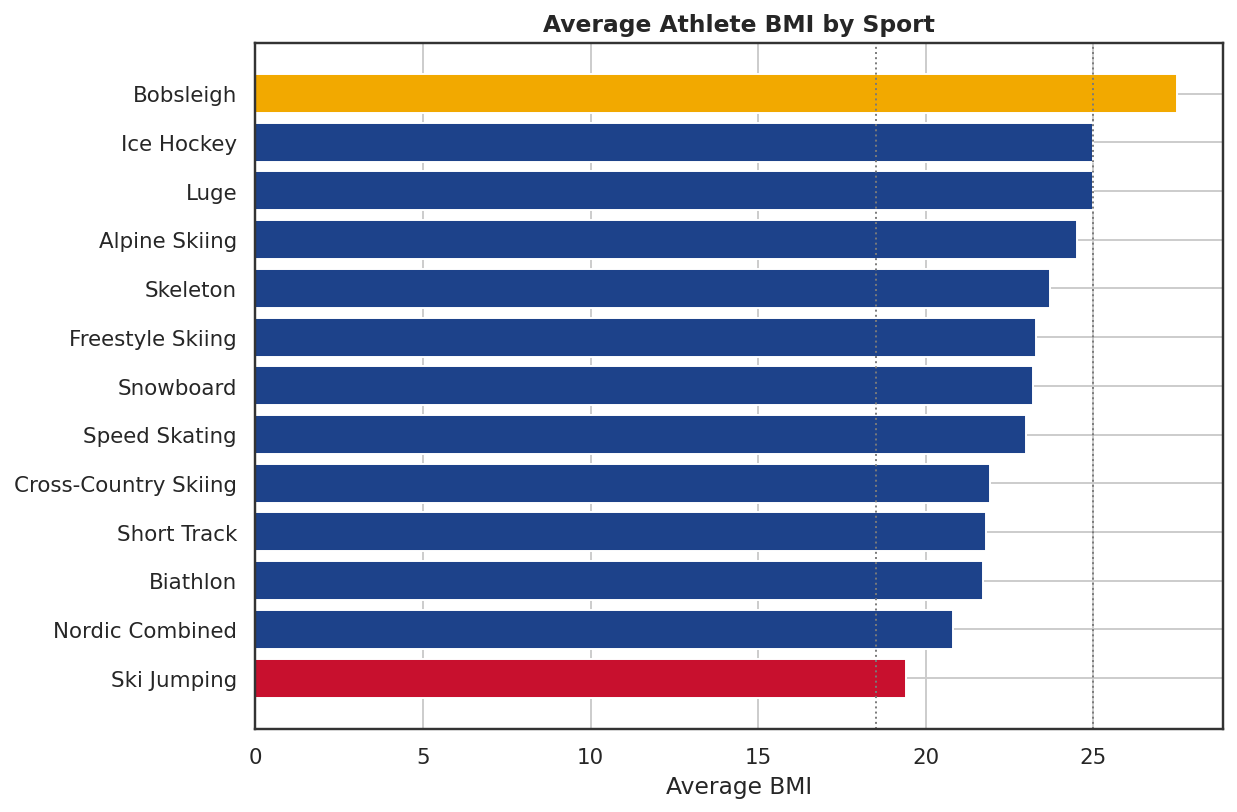

In [2]:
fig, ax = plt.subplots(figsize=(9,6))
d = ss.dropna(subset=['avg_bmi']).sort_values('avg_bmi')
colors = ['#C8102E' if v < 20.5 else ('#F2A900' if v > 26 else '#1D428A') for v in d['avg_bmi']]
ax.barh(d['sport'], d['avg_bmi'], color=colors)
ax.axvline(18.5, color='#7A7A7A', linestyle=':', linewidth=1)  # WHO underweight threshold
ax.axvline(25, color='#7A7A7A', linestyle=':', linewidth=1)    # WHO overweight threshold
ax.set_xlabel('Average BMI'); ax.set_title('Average Athlete BMI by Sport')
plt.show()

## 3. Data quality check: is the BMI gap by sport real, or a missing-data artifact?

Weight is missing for 326 athletes overall — but not randomly.

In [3]:
missing_by_sport = df.groupby('sport')['weight_kg'].apply(lambda s: s.isna().sum()).sort_values(ascending=False)
print(missing_by_sport)

sport
Figure Skating          146
Curling                  99
Cross-Country Skiing     21
Biathlon                 11
Speed Skating            11
Snowboard                10
Alpine Skiing             9
Freestyle Skiing          7
Nordic Combined           5
Ski Jumping               5
Skeleton                  2
Bobsleigh                 1
Short Track               0
Ice Hockey                0
Luge                      0


**100% of Figure Skating and Curling athletes have missing weight** — a structural recording gap for those two sports specifically, not random missingness. No BMI conclusion is possible for either sport, and none is drawn here.

## 4. Delegation size: the largest national teams

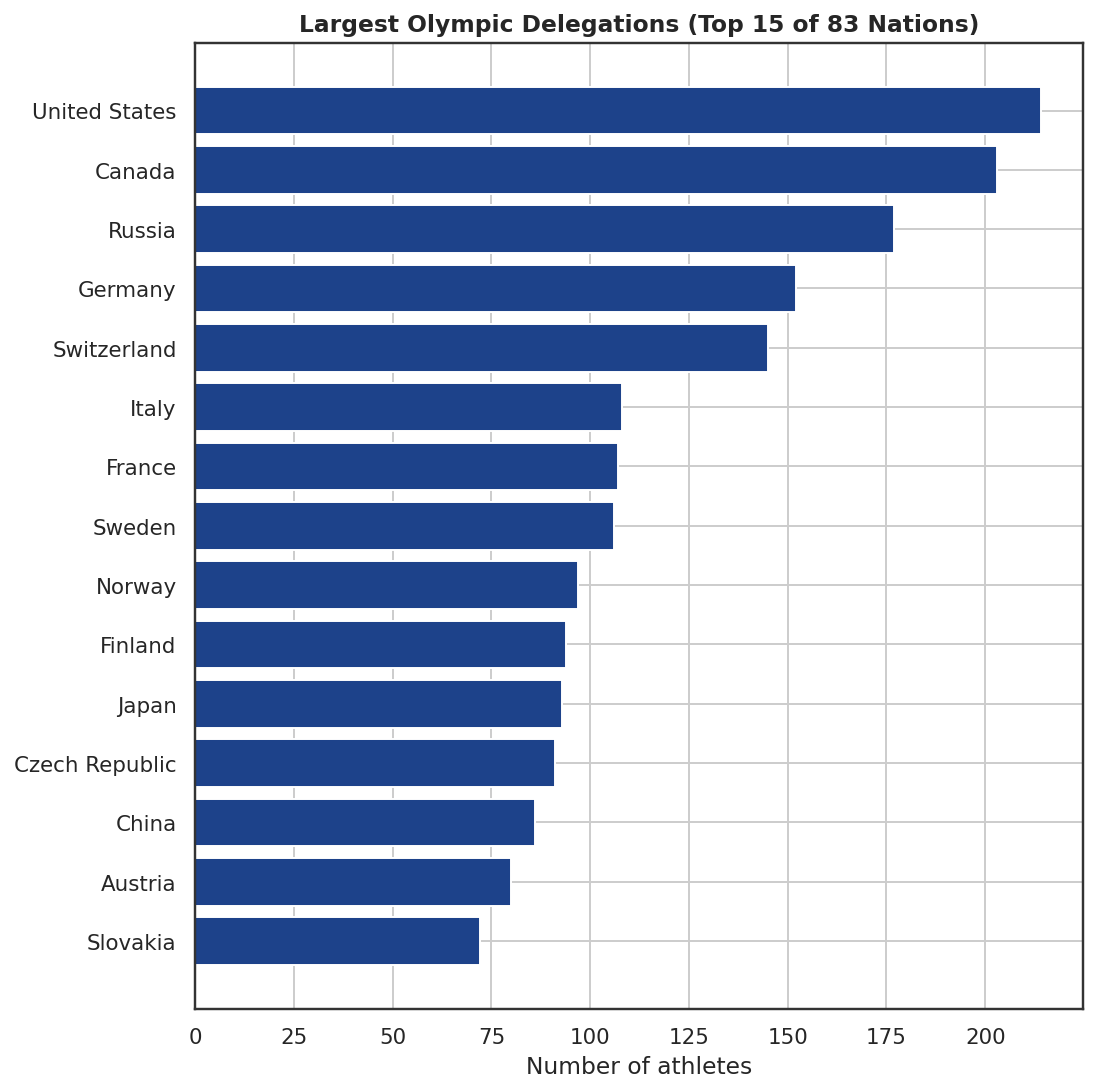

In [4]:
fig, ax = plt.subplots(figsize=(8,8))
top15 = cs.nlargest(15, 'athlete_count').sort_values('athlete_count')
ax.barh(top15['nationality'], top15['athlete_count'], color='#1D428A')
ax.set_xlabel('Number of athletes'); ax.set_title('Largest Olympic Delegations (Top 15 of 83 Nations)')
plt.show()

## 5. The map: delegation size by country, without internet access

This environment has no internet access, so `plotly` and `geopandas` (and the
shapefiles/GeoJSON they need to draw country boundaries) aren't available. This
map uses a different, genuinely common technique instead: a **geographic bubble
map** — plotting each country at its real (latitude, longitude) centroid on a
plain coordinate grid, with bubble size and color both encoding delegation size.
No shapefile, boundary file, or external service is needed — just real
coordinates (`src/country_coords.py`) and matplotlib's ordinary scatter plot.

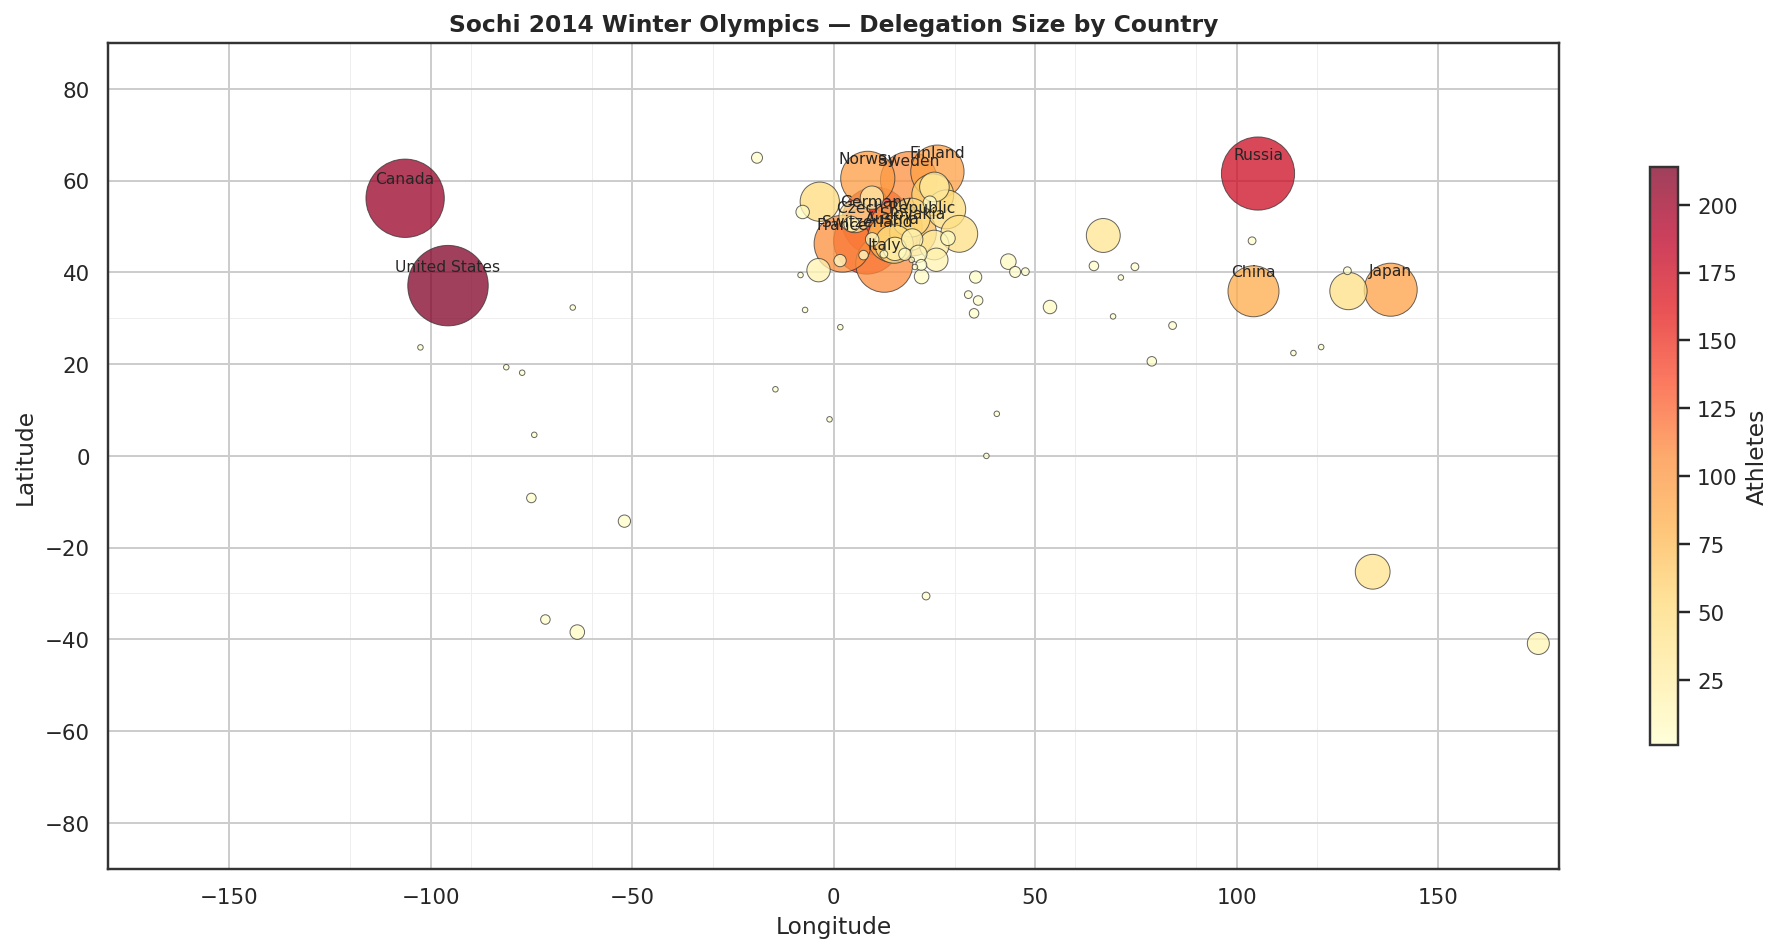

In [5]:
import sys
sys.path.insert(0, 'src')
from country_coords import COUNTRY_COORDS  # {country: (lat, lon)} for all 83 nations

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(-180, 180); ax.set_ylim(-90, 90)

# Faint lat/lon reference grid, standing in for a coastline/border basemap
ax.axhline(0, color='#cccccc', linewidth=0.5); ax.axvline(0, color='#cccccc', linewidth=0.5)
for lat in range(-60, 90, 30):
    ax.axhline(lat, color='#eeeeee', linewidth=0.5, zorder=0)
for lon in range(-150, 180, 30):
    ax.axvline(lon, color='#eeeeee', linewidth=0.5, zorder=0)

# Plot every country at its real centroid, sized + colored by delegation size
lats, lons, sizes, labels = [], [], [], []
for _, row in cs.iterrows():
    coord = COUNTRY_COORDS.get(row['nationality'])
    if coord:
        lats.append(coord[0]); lons.append(coord[1]); sizes.append(row['athlete_count'])
        labels.append((row['nationality'], coord, row['athlete_count']))

sc = ax.scatter(lons, lats, s=[s * 8 for s in sizes], c=sizes, cmap='YlOrRd',
                 alpha=0.75, edgecolor='#333333', linewidth=0.5, zorder=3)

# Label only the largest delegations, to keep the map readable
for name, (lat, lon), cnt in labels:
    if cnt >= 60:
        ax.annotate(name, (lon, lat), fontsize=8, ha='center', va='bottom',
                     xytext=(0, 6), textcoords='offset points')

fig.colorbar(sc, ax=ax, label='Athletes', shrink=0.7)
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')
ax.set_title('Sochi 2014 Winter Olympics — Delegation Size by Country')
plt.show()

## 6. Age distribution by sport

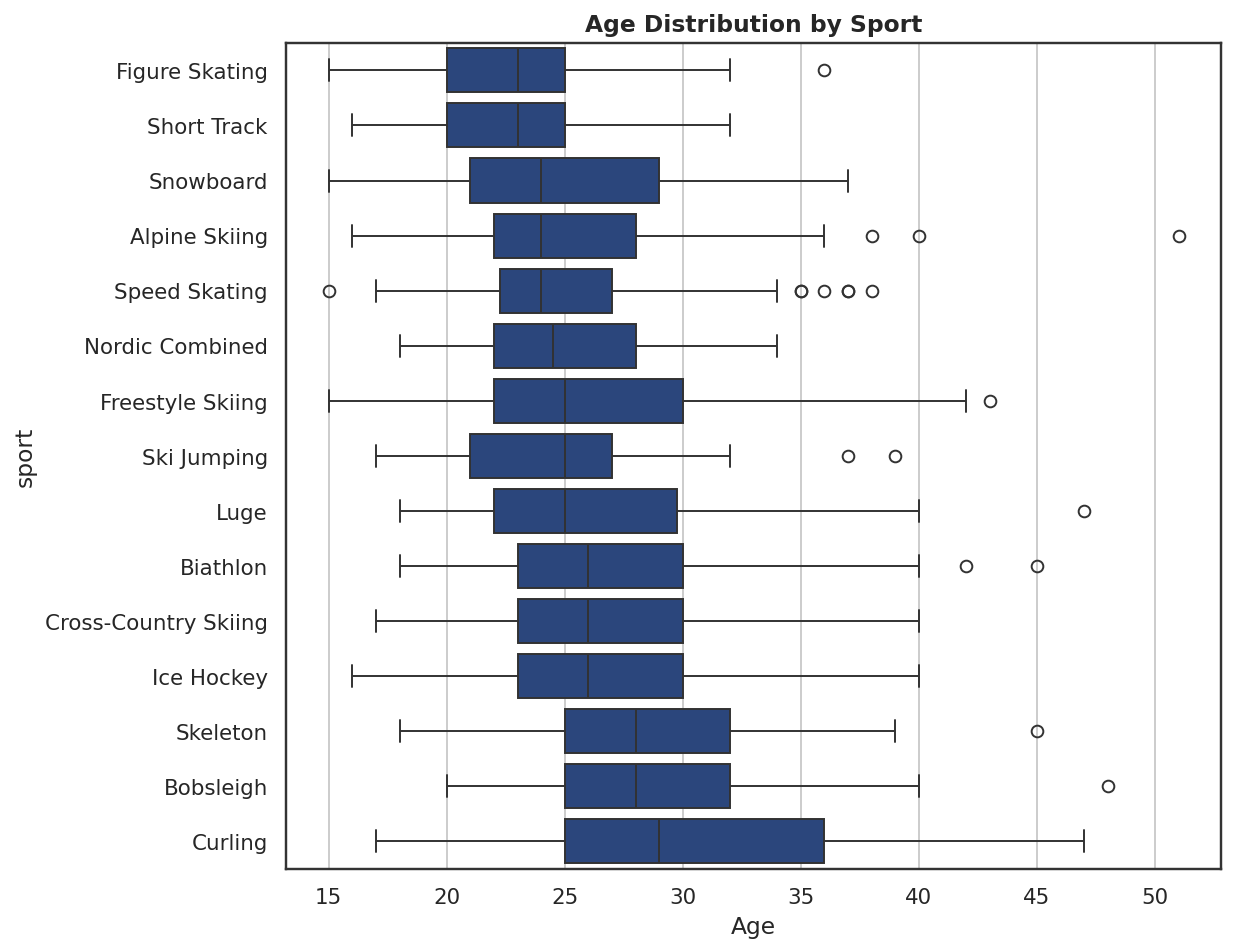

In [6]:
fig, ax = plt.subplots(figsize=(9,7))
order = df.groupby('sport')['age'].median().sort_values().index
sns.boxplot(data=df, y='sport', x='age', order=order, ax=ax, color='#1D428A')
ax.set_xlabel('Age'); ax.set_title('Age Distribution by Sport')
plt.show()

## 7. Conclusions

- Ski Jumping's average BMI (19.4) sits at the edge of the WHO underweight
  threshold — consistent with well-documented historical concerns about
  weight-cutting in the sport, which led to BMI-linked equipment regulations.
- Figure Skating and Curling have a complete, structural weight-data gap
  (100% missing) — no BMI conclusion is possible for either, and this is
  reported directly rather than left as a silent hole in the analysis.
- 18 of 83 nations sent exactly one athlete, while the U.S. and Canada alone
  account for roughly 16% of the entire roster — a real participation
  imbalance, visible directly on the geographic map.
- The map was built without internet access or a mapping library, using real
  country coordinates and matplotlib — a genuinely usable technique when
  `plotly`/`geopandas` and their shapefiles aren't available.
